## Experiment: Mini Project / AI Application

### Simple Example: Introduction to Linear Regression

This simple example introduces the fundamental concept of linear regression, which is a basic supervised learning algorithm. It demonstrates how to predict a continuous output variable based on one or more input features. Here, we'll use a single feature to predict a target variable, simulating a simple relationship like 'hours studied' vs. 'exam score'.

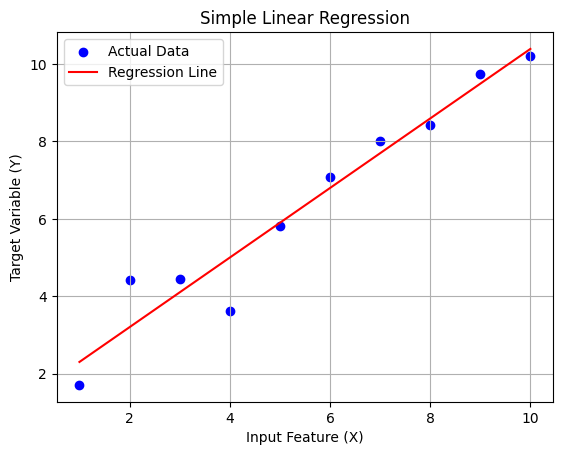

Intercept: 1.40
Coefficient: 0.90


In [1]:
# Import necessary libraries
import numpy as np # NumPy is used for numerical operations, especially with arrays.
import matplotlib.pyplot as plt # Matplotlib is used for plotting graphs.
from sklearn.linear_model import LinearRegression # Scikit-learn's LinearRegression model.

# 1. Generate some synthetic data for demonstration
# X represents the input feature (e.g., hours studied).
x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10]).reshape(-1, 1) # Create a 2D array for features.
# y represents the target variable (e.g., exam score), with some noise.
y = np.array([2, 4, 5, 4, 6, 7, 8, 9, 10, 11]) + np.random.normal(0, 0.5, size=x.shape[0])

# 2. Create a Linear Regression model instance
model = LinearRegression() # Initialize the linear regression model.

# 3. Train the model using the data
model.fit(x, y) # 'fit' means to train the model on the provided data (x: features, y: target).

# 4. Make predictions using the trained model
y_pred = model.predict(x) # Use the trained model to predict y values for the given x.

# 5. Visualize the results
plt.scatter(x, y, color='blue', label='Actual Data') # Plot the actual data points as a scatter plot.
plt.plot(x, y_pred, color='red', label='Regression Line') # Plot the regression line (predictions).
plt.title('Simple Linear Regression') # Set the title of the plot.
plt.xlabel('Input Feature (X)') # Label for the x-axis.
plt.ylabel('Target Variable (Y)') # Label for the y-axis.
plt.legend() # Display the legend to identify actual data and regression line.
plt.grid(True) # Add a grid to the plot for better readability.
plt.show() # Display the plot.

# Print the coefficients of the linear regression model
print(f"Intercept: {model.intercept_:.2f}") # The y-intercept of the regression line.
print(f"Coefficient: {model.coef_[0]:.2f}") # The slope of the regression line (how much Y changes per unit change in X). # [0] because it's a single feature.

### Complex Application: Image Classification with a Pre-trained Model

This example demonstrates a more complex AI application: image classification using a pre-trained Convolutional Neural Network (CNN). We'll use `tf.keras` to load a `MobileNetV2` model, which is already trained on a large dataset (ImageNet). This allows us to classify new images without extensive training, showcasing transfer learning – a powerful technique in deep learning.

In [4]:
# Import necessary libraries
import tensorflow as tf # TensorFlow is an open-source machine learning framework.
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions # Import MobileNetV2 model and its utilities.
from tensorflow.keras.preprocessing import image # Utilities for image preprocessing.
import numpy as np # NumPy for numerical operations.
import requests # To download an image from a URL.
from PIL import Image # Pillow for image manipulation.
from io import BytesIO # To handle binary data from the image download.

# 1. Load a pre-trained MobileNetV2 model
# weights='imagenet' means the model is initialized with weights trained on the ImageNet dataset.
model = MobileNetV2(weights='imagenet')

# 2. Function to load and preprocess an image
def load_and_preprocess_image(img_path):
    if img_path.startswith('http'):
        # If it's a URL, download the image
        response = requests.get(img_path) # Send an HTTP GET request to the URL.
        img = Image.open(BytesIO(response.content)) # Open the image from the downloaded content.
        img = img.resize((224, 224)) # Explicitly resize the image to 224x224 pixels for the model.
    else:
        # If it's a local path, load the image directly
        img = image.load_img(img_path, target_size=(224, 224)) # Load image and resize to 224x224 pixels (MobileNetV2's input size).

    img_array = image.img_to_array(img) # Convert the PIL image instance to a NumPy array.
    img_array = np.expand_dims(img_array, axis=0) # Add an extra dimension for the batch (model expects a batch of images).
    img_array = preprocess_input(img_array) # Preprocess the image for MobileNetV2 (e.g., scaling pixel values).
    return img_array

# 3. Define an image URL to classify
image_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg' # Updated to a more reliable image URL
print(f"Classifying image from: {image_url}")

# 4. Load and preprocess the image
processed_image = load_and_preprocess_image(image_url)

# 5. Make a prediction
predictions = model.predict(processed_image) # Get raw predictions (probabilities) from the model.

# 6. Decode and display the top 3 predictions
# decode_predictions converts the numerical predictions into human-readable labels.
# top=3 specifies that we want the top 3 most likely classifications.
decoded_predictions = decode_predictions(predictions, top=3)[0]

print("\nTop 3 Predictions:") # Print a header for the predictions.
for i, (imagenet_id, label, score) in enumerate(decoded_predictions):
    # Iterate through each prediction and print its rank, label, and confidence score.
    print(f"{i+1}: {label} ({score*100:.2f}%) ")

Classifying image from: https://storage.googleapis.com/download.tensorflow.org/example_images/grace_hopper.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

Top 3 Predictions:
1: military_uniform (81.48%) 
2: bearskin (1.82%) 
3: mortarboard (1.50%) 
